> #### Environment Setup
> Copy the following line to the terminal
> ```cmd
> pip install matplotlib seaborn numpy scipy scikit-learn tensorflow yfinance
> ```

# Plan
1. Fetch Data
2. Generate All Candidate Features (technical indicators, returns, ratios, time)
3. Forward Selection — find the best feature subset
4. Data Preparation — selected features, train/test split **before** scaling, RobustScaler
5. Build & Train LSTM — two LSTM layers with Dropout, EarlyStopping
6. Predict & Visualize
7. Evaluate — RMSE, MAE, MAPE

# 0. Setup and Dependencies

In [25]:
%pip install matplotlib seaborn numpy pandas scipy scikit-learn tensorflow yfinance fredapi vaderSentiment google-news-api dateparser --quiet
import yfinance as yf
from fredapi import Fred
import seaborn as sns
import numpy as np
import pandas as pd
import time, requests
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_squared_error, r2_score

---
# 1. Fetching Stock Data

In [26]:
# ── Config ──────────────────────────────────────────────────────────────────
TICKER     = 'TSLA'          # Change to any yfinance-supported ticker
START_DATE = '2016-01-01'
END_DATE   = '2025-12-31'

stock_data = yf.download(TICKER, start=START_DATE, end=END_DATE, multi_level_index=False)
print(f'Downloaded {len(stock_data)} rows for {TICKER}')
stock_data.tail()


/tmp/ipykernel_973/187181836.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(TICKER, start=START_DATE, end=END_DATE, multi_level_index=False)
[*********************100%***********************]  1 of 1 completed

Downloaded 2513 rows for TSLA


,Close,High,Low,Open,Volume
Date,,,,,
2025-12-23,485.559998,491.970001,482.839996,489.399994,58223600
2025-12-24,485.399994,490.899994,476.799988,488.480011,41285400
2025-12-26,475.190002,489.089996,473.820007,485.230011,58780700
2025-12-29,459.640015,469.399994,459.000000,469.000000,66263000
2025-12-30,454.429993,463.119995,453.829987,461.089996,59238500


---
# 2. Generate All Candidate Features

### 2.0 Configuration

In [27]:
import os

# Set keys as environment variables (recommended) or paste them directly here.
# FRED key  : https://fred.stlouisfed.org/docs/api/api_key.html  (free)
# AV key    : https://www.alphavantage.co/support/#api-key        (free, 25 req/day)
FRED_API_KEY          = os.environ.get('FRED_API_KEY',   '5e48206e559ddc72e7679880d1a2534f')
ALPHA_VANTAGE_API_KEY = os.environ.get('ALPHA_VANTAGE_KEY', '5D7686ZMEGMVYECL')

# Pull macro data earlier so rolling windows are warm at TRAIN_START
MACRO_START = '2016-01-01'


### 2.1 Technical Features

In [28]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

df = stock_data.copy()

# --- Moving averages & volatility ---
for w in [5, 10, 20, 50]:
    df[f'SMA_{w}']        = df['Close'].rolling(w).mean()
    df[f'EMA_{w}']        = df['Close'].ewm(span=w).mean()
    df[f'Volatility_{w}'] = df['Close'].pct_change().rolling(w).std()

# RSI-14
df['RSI_14'] = 100 - 100 / (
    1 + df['Close'].diff().clip(lower=0).rolling(14).mean()
      / df['Close'].diff().clip(upper=0).abs().rolling(14).mean()
)

# MACD
ema12 = df['Close'].ewm(span=12).mean()
ema26 = df['Close'].ewm(span=26).mean()
df['MACD']        = ema12 - ema26
df['MACD_signal'] = df['MACD'].ewm(span=9).mean()
df['MACD_hist']   = df['MACD'] - df['MACD_signal']

# Bollinger Bands
sma20 = df['Close'].rolling(20).mean()
std20 = df['Close'].rolling(20).std()
df['BB_upper'] = sma20 + 2 * std20
df['BB_lower'] = sma20 - 2 * std20
df['BB_width'] = (df['BB_upper'] - df['BB_lower']) / sma20

# ATR-14
high_low  = df['High'] - df['Low']
high_prev = (df['High'] - df['Close'].shift(1)).abs()
low_prev  = (df['Low']  - df['Close'].shift(1)).abs()
df['ATR_14'] = pd.concat([high_low, high_prev, low_prev], axis=1).max(axis=1).rolling(14).mean()

# OBV
df['OBV'] = (np.sign(df['Close'].diff()) * df['Volume']).cumsum()

# --- Returns ---
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
df['return_1d']  = df['Close'].pct_change()
df['return_5d']  = df['Close'].pct_change(5)

# --- Price ratios ---
df['high_low_ratio']   = df['High'] / df['Low']
df['close_open_ratio'] = df['Close'] / df['Open']

# --- Cyclical time features ---
# np.where avoids pandas ExtensionArray issues with is_leap_year
year_days = np.where(df.index.is_leap_year, 366, 365)
df['sin_year']    = np.sin(2 * np.pi * (df.index.dayofyear - 1) / year_days)
df['cos_year']    = np.cos(2 * np.pi * (df.index.dayofyear - 1) / year_days)
df['day_of_week'] = df.index.dayofweek / 6.0

# isocalendar().week returns an ExtensionArray — cast to float before numpy ops
week_num = df.index.isocalendar().week.values.astype(float)
df['sin_week'] = np.sin(2 * np.pi * (week_num - 1) / 52)
df['cos_week'] = np.cos(2 * np.pi * (week_num - 1) / 52)

df['sin_month']   = np.sin(2 * np.pi * (df.index.month   - 1) / 12)
df['cos_month']   = np.cos(2 * np.pi * (df.index.month   - 1) / 12)
df['sin_quarter'] = np.sin(2 * np.pi * (df.index.quarter - 1) / 4)
df['cos_quarter'] = np.cos(2 * np.pi * (df.index.quarter - 1) / 4)

# Days since start - monotonic time feature (critical for trending stocks)
df['days_since_start'] = np.arange(len(df))

# Target: next-day close
df['Close_nxt'] = df['Close'].shift(-1)
df = df.dropna()

print(f'Technical features shape: {df.shape}')


Technical features shape: (2462, 42)


### 2.2 Macro Feature (Pulled from FRED)
| Series | FRED Code | Why It Helps |
|---|---|---|
| VIX | `VIXCLS` | Market fear gauge — spikes before and during crashes |
| Yield curve (10Y-2Y) | `T10Y2Y` | Inversion reliably precedes recessions |
| Fed Funds Rate | `FEDFUNDS` | Rate hike cycles crush tech/growth stocks |
| CPI (Inflation) | `CPIAUCSL` | High inflation = rate hikes = market pressure |
| Credit spread (BAA-AAA) | computed | Widens before financial stress events |
| M2 Money Supply | `M2SL` | Liquidity proxy — correlated with equity returns |
| Unemployment | `UNRATE` | Lagging but useful for recession regime detection |

In [29]:
def fetch_macro_data(fred_api_key, start_date, end_date):
    """
    Pull key macro series from FRED and combine into a weekly DataFrame.

    All series are resampled to weekly frequency (last value of each week)
    to align with the stock price interval. Forward-fill is used for
    series that report monthly (e.g. CPI, unemployment).

    Parameters
    ----------
    fred_api_key : str  — from https://fred.stlouisfed.org
    start_date   : str  — pull from here (earlier than train start to warm windows)
    end_date     : str  — pull until here

    Returns
    -------
    pd.DataFrame indexed by Date (weekly), columns = macro feature names
    """
    if fred_api_key == 'YOUR_FRED_KEY_HERE':
        print('⚠️  No FRED API key set — returning empty macro frame.')
        print('   Get a free key at: https://fred.stlouisfed.org/docs/api/api_key.html')
        # Return empty DataFrame so the rest of the notebook still runs
        return pd.DataFrame()

    fred = Fred(api_key=fred_api_key)

    # ── Series to pull ────────────────────────────────────────────────────────
    SERIES = {
        'vix'         : 'VIXCLS',    # CBOE Volatility Index (daily → weekly)
        'yield_curve' : 'T10Y2Y',    # 10Y minus 2Y Treasury spread
        'fed_funds'   : 'FEDFUNDS',  # Effective Federal Funds Rate
        'cpi'         : 'CPIAUCSL',  # CPI All Items (monthly)
        'baa_rate'    : 'BAA',       # Moody's BAA corporate bond yield
        'aaa_rate'    : 'AAA',       # Moody's AAA corporate bond yield
        'm2'          : 'M2SL',      # M2 money supply (monthly)
        'unemployment': 'UNRATE',    # Unemployment rate (monthly)
    }

    frames = {}
    for name, code in SERIES.items():
        try:
            s = fred.get_series(code, observation_start=start_date, observation_end=end_date)
            # Resample to weekly, forward-fill gaps (monthly data spans multiple weeks)
            s = s.resample('W').last().ffill()
            frames[name] = s
            print(f'  ✓ {name} ({code}): {len(s)} weekly observations')
        except Exception as e:
            print(f'  ✗ {name} ({code}): {e}')

    macro_df = pd.DataFrame(frames)
    macro_df.index = pd.to_datetime(macro_df.index)

    # ── Derived macro features ────────────────────────────────────────────────
    if 'baa_rate' in macro_df and 'aaa_rate' in macro_df:
        # Credit spread: difference between high-yield (BAA) and investment-grade (AAA)
        # When this widens rapidly, credit markets are under stress — a leading crash signal
        macro_df['credit_spread'] = macro_df['baa_rate'] - macro_df['aaa_rate']

    if 'vix' in macro_df:
        # VIX percentile rank over trailing 52 weeks (puts current fear in context)
        macro_df['vix_percentile'] = macro_df['vix'].rolling(52).rank(pct=True)
        # VIX spike flag: current VIX > 1.5× its 52-week rolling mean
        macro_df['vix_spike']      = (macro_df['vix'] > macro_df['vix'].rolling(52).mean() * 1.5).astype(int)

    if 'yield_curve' in macro_df:
        # Yield curve inversion flag: when 2Y yield > 10Y yield, recession risk is elevated
        # Has preceded every US recession since 1955
        macro_df['yield_inverted'] = (macro_df['yield_curve'] < 0).astype(int)

    if 'cpi' in macro_df:
        # Year-over-year CPI change — captures inflation acceleration/deceleration
        macro_df['cpi_yoy'] = macro_df['cpi'].pct_change(52) * 100  # 52 weeks ≈ 1 year

    if 'm2' in macro_df:
        # M2 growth rate: rapid expansion = liquidity-driven rallies;
        # contraction = liquidity crunch (2022 bear market coincided with M2 contraction)
        macro_df['m2_yoy'] = macro_df['m2'].pct_change(52) * 100

    print(f'\nMacro DataFrame shape: {macro_df.shape}')
    return macro_df


macro_df = fetch_macro_data(FRED_API_KEY, MACRO_START, END_DATE)
if not macro_df.empty:
    macro_df.tail()

  ✓ vix (VIXCLS): 523 weekly observations
  ✓ yield_curve (T10Y2Y): 523 weekly observations
  ✓ fed_funds (FEDFUNDS): 519 weekly observations
  ✓ cpi (CPIAUCSL): 519 weekly observations
  ✓ baa_rate (BAA): 519 weekly observations
  ✓ aaa_rate (AAA): 519 weekly observations
  ✓ m2 (M2SL): 519 weekly observations
  ✓ unemployment (UNRATE): 519 weekly observations

Macro DataFrame shape: (523, 14)


/tmp/ipykernel_973/4236747116.py:72: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  macro_df['cpi_yoy'] = macro_df['cpi'].pct_change(52) * 100  # 52 weeks ≈ 1 year
/tmp/ipykernel_973/4236747116.py:77: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  macro_df['m2_yoy'] = macro_df['m2'].pct_change(52) * 100


### 2.3 Sentiment Data (from Google RSS and VADER)

In [30]:
try:
    from google_news_api import GoogleNewsClient
    _GNEWS_AVAILABLE = True
except ImportError:
    _GNEWS_AVAILABLE = False
    print('⚠️  google-news-api not installed — sentiment features will be skipped.')

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from datetime import date
from dateutil.parser import parse as _parse_date


def fetch_google_news_rss(query='Apple', topic='TECHNOLOGY',
                          start_date=None, end_date=None):
    """
    Fetch Google News articles and score them with VADER sentiment.

    Returns a DataFrame indexed by Date with daily-aggregated columns:
    sentiment_mean, sentiment_pos, sentiment_neg.
    Returns an empty DataFrame when the library is unavailable or the fetch fails.
    """
    if not _GNEWS_AVAILABLE:
        return pd.DataFrame()

    today = str(date.today())          # fixed: date.today() not date.today
    start_date = start_date or today
    end_date   = end_date   or today

    print(f'\n\U0001f4f0 Fetching Google News: query={query!r}  {start_date} \u2192 {end_date}')

    analyzer = SentimentIntensityAnalyzer()
    client   = GoogleNewsClient(language='en', country='US', requests_per_minute=120)
    records  = []

    start_str = str(_parse_date(start_date.strip()).date())
    end_str   = str(_parse_date(end_date.strip()).date())

    try:
        articles = client.search(query, after=start_str, before=end_str, max_results=10_000)

        for article in articles:
            try:
                title     = article.get('title', '')
                summary   = article.get('summary', '')
                published = article.get('published') or article.get('pubDate', '')
                try:
                    pub_date = pd.to_datetime(published).normalize()
                except Exception:
                    pub_date = pd.Timestamp.now().normalize()

                scores = analyzer.polarity_scores(f'{title} {summary}'.strip())
                records.append({
                    'Date':           pub_date,
                    'sentiment_mean': scores['compound'],
                    'sentiment_pos':  scores['pos'],
                    'sentiment_neg':  scores['neg'],
                })
            except Exception:
                continue

        if not records:
            print('\u26a0\ufe0f  No articles found \u2014 returning empty sentiment frame.')
            return pd.DataFrame()

        df_sent = pd.DataFrame(records)
        df_sent['Date'] = pd.to_datetime(df_sent['Date'])

        # Aggregate to one row per calendar day (no 'headline' text column)
        df_sent = (
            df_sent.groupby('Date')[['sentiment_mean', 'sentiment_pos', 'sentiment_neg']]
            .mean()
        )

        print(f'\u2705 {len(df_sent)} daily sentiment rows  |  '
              f'avg compound: {df_sent["sentiment_mean"].mean():+.3f}')
        return df_sent

    except Exception as e:
        print(f'\u274c Fetch error: {e}')
        return pd.DataFrame()


# ── Dynamic Sentiment Queries Based on TICKER ─────────────────────────────────
GENERIC_TERMS = ['stock', 'earnings', 'quarterly', 'revenue', 'forecast', 'news']

TICKER_QUERIES = {
    'TSLA': ['Tesla', 'Elon Musk', 'Model Y', 'Model 3', 'Cybertruck', 'EV'],
    'AAPL': ['Apple', 'iPhone', 'MacBook', 'Apple AI', 'iPad'],
    'MSFT': ['Microsoft', 'Windows', 'Azure', 'OpenAI'],
    'GOOGL': ['Google', 'Android', 'YouTube', 'Gemini AI'],
    'AMZN': ['Amazon', 'AWS', 'Prime', 'e-commerce'],
    'NVDA': ['Nvidia', 'GPU', 'AI chips', 'CUDA'],
    'META': ['Meta', 'Facebook', 'VR', 'Reality Labs'],
}

def get_ticker_queries(ticker):
    if ticker.upper() in TICKER_QUERIES:
        return TICKER_QUERIES[ticker.upper()][:6]
    return [ticker.upper()] + [f'{ticker} {term}' for term in GENERIC_TERMS[:5]]

queries = get_ticker_queries(TICKER)
print(f"Using sentiment queries for {TICKER}: {queries}")

# Fetch sentiment from dynamic queries and combine
combined_dfs = []
for q in queries:
    sentiment_data = fetch_google_news_rss(query=q, start_date=START_DATE, end_date=END_DATE)
    if not sentiment_data.empty:
        combined_dfs.append(sentiment_data)
        print(f"  {q}: {len(sentiment_data)} rows")

if combined_dfs:
    sentiment_df = pd.concat(combined_dfs)
    sentiment_df = sentiment_df.groupby(sentiment_df.index).mean()
    sentiment_df = sentiment_df.loc[:, ~sentiment_df.columns.duplicated()]
    print(f"Combined sentiment: {len(sentiment_df)} daily rows")
else:
    sentiment_df = pd.DataFrame()
    print("No sentiment data fetched")


Using sentiment queries for TSLA: ['Tesla', 'Elon Musk', 'Model Y', 'Model 3', 'Cybertruck', 'EV']

📰 Fetching Google News: query='Tesla'  2016-01-01 → 2025-12-31
✅ 96 daily sentiment rows  |  avg compound: +0.004
  Tesla: 96 rows

📰 Fetching Google News: query='Elon Musk'  2016-01-01 → 2025-12-31
✅ 87 daily sentiment rows  |  avg compound: -0.062
  Elon Musk: 87 rows

📰 Fetching Google News: query='Model Y'  2016-01-01 → 2025-12-31
✅ 78 daily sentiment rows  |  avg compound: +0.109
  Model Y: 78 rows

📰 Fetching Google News: query='Model 3'  2016-01-01 → 2025-12-31
✅ 96 daily sentiment rows  |  avg compound: +0.114
  Model 3: 96 rows

📰 Fetching Google News: query='Cybertruck'  2016-01-01 → 2025-12-31
✅ 89 daily sentiment rows  |  avg compound: -0.077
  Cybertruck: 89 rows

📰 Fetching Google News: query='EV'  2016-01-01 → 2025-12-31
✅ 92 daily sentiment rows  |  avg compound: +0.158
  EV: 92 rows
Combined sentiment: 421 daily rows


### Options Data (Historical Time Series)
> **Why Options?**
> - The put/call ratio measures how many put (bearish bet) contracts are being bought relative to call (bullish bet) contracts. A high PCR > 1 means traders are paying to protect against downside — a leading signal for fear and potential reversals.
> - **Implied Volatility (IV)** captures market's expectation of future volatility - often leads price movements
> - **IV Skew** (put IV - call IV) shows demand for downside protection
> 
> **Data Source**: [Alpha Vantage](https://www.alphavantage.co/)
> - Free historical put-call ratio (monthly frequency)
> - Other features from yfinance snapshot
> - Get free API key at https://www.alphavantage.co/support/#api-key (25 requests/day)

In [31]:
def fetch_historical_options_features(ticker, start_date, end_date):
    """
    Fetch historical options data: put_call_ratio from Alpha Vantage (monthly), other features from yfinance snapshot.
    
    Uses Alpha Vantage for historical put-call ratio (monthly frequency to respect free tier limits).
    Other features (IV, volume, OI) are fetched as current snapshot from yfinance.
    
    Parameters
    ----------
    ticker    : str - stock ticker symbol (uppercase)
    start_date : str - start date (YYYY-MM-DD)
    end_date  : str - end date (YYYY-MM-DD)
    
    Returns
    -------
    pd.DataFrame indexed by date with columns: put_call_ratio, implied_vol_call,
    implied_vol_put, iv_skew, call_volume, put_volume, call_oi, put_oi
    """
    
    api_key = ALPHA_VANTAGE_API_KEY
    if api_key == 'YOUR_KEY_HERE':
        print('⚠️  No Alpha Vantage API key set — returning empty options frame.')
        print('   Get a free key at: https://www.alphavantage.co/support/#api-key')
        return pd.DataFrame()
    
    # Generate monthly end dates (last day of each month)
    dates = pd.date_range(start=start_date, end=end_date, freq='ME')
    records = []
    
    for date in dates:
        date_str = date.strftime('%Y-%m-%d')
        url = f'https://www.alphavantage.co/query?function=HISTORICAL_PUT_CALL_RATIO&symbol={ticker}&date={date_str}&apikey={api_key}'
        try:
            response = requests.get(url)
            data = response.json()
            pcr = data.get('put_call_ratio_full_chain')
            if pcr:
                records.append({'date': date, 'put_call_ratio': float(pcr)})
            time.sleep(1)  # Respect rate limit (25 req/day)
        except Exception as e:
            print(f'Error fetching for {date_str}: {e}')
    
    options_df = pd.DataFrame(records)
    if options_df.empty:
        return pd.DataFrame()
    
    options_df['date'] = pd.to_datetime(options_df['date'])
    options_df = options_df.set_index('date')
    
    # For other features, use yfinance snapshot
    try:
        t = yf.Ticker(ticker)
        exp = t.options
        if not exp:
            print("No options expirations available")
            return options_df  # Return only PCR data
        
        chain = t.option_chain(exp[0])
        calls = chain.calls
        puts = chain.puts
        
        call_vol = calls['volume'].sum()
        put_vol = puts['volume'].sum()
        call_oi = calls['openInterest'].sum()
        put_oi = puts['openInterest'].sum()
        
        mid = len(calls) // 2
        iv_call = calls['impliedVolatility'].iloc[max(0, mid-3):mid+3].mean()
        iv_put = puts['impliedVolatility'].iloc[max(0, mid-3):mid+3].mean()
        
        # Add these as constant columns
        options_df['implied_vol_call'] = iv_call
        options_df['implied_vol_put'] = iv_put
        options_df['iv_skew'] = iv_put - iv_call
        options_df['call_volume'] = call_vol
        options_df['put_volume'] = put_vol
        options_df['call_oi'] = call_oi
        options_df['put_oi'] = put_oi
        
    except Exception as e:
        print(f'Error fetching yfinance data: {e}')
    
    return options_df

options_df = fetch_historical_options_features(TICKER, START_DATE, END_DATE)

In [32]:
os.makedirs('data', exist_ok=True)   # safe on Colab, Kaggle, VS Code, local

macro_df.to_csv('data/macro_data.csv')
sentiment_df.to_csv('data/sentiment.csv')
options_df.to_csv('data/options.csv')
df.to_csv(f'data/stock_data_{TICKER}.csv')
print('\u2705 Raw data saved to data/')


✅ Raw data saved to data/


## Data Pre-Processing

### Merge and Clean Data

In [33]:
# Ensure all indices are timezone-naive datetime
def _to_utc_naive(idx):
    idx = pd.to_datetime(idx)
    return idx.tz_localize(None) if idx.tzinfo is not None else idx

df.index           = _to_utc_naive(df.index)
macro_df.index     = _to_utc_naive(macro_df.index)
sentiment_df.index = _to_utc_naive(sentiment_df.index)
options_df.index   = _to_utc_naive(options_df.index)


def _resample_to_daily(src, target_index):
    """Forward-fill a lower-frequency frame to daily, keeping only numeric cols."""
    if src.empty:
        return pd.DataFrame(index=target_index)
    return (
        src.select_dtypes(include=[np.number])
           .reindex(target_index, method='ffill')
    )


macro_daily     = _resample_to_daily(macro_df,     df.index)
sentiment_daily = _resample_to_daily(sentiment_df, df.index)
options_daily   = _resample_to_daily(options_df,   df.index)


# Safeguard: reload df from CSV if missing stock columns
if 'Close' not in df.columns or 'High' not in df.columns:
    print("WARNING: df missing stock columns, reloading from CSV...")
    df = pd.read_csv(f'data/stock_data_{TICKER}.csv', index_col=0, parse_dates=True)
    print(f'Reloaded df shape: {df.shape}')

# Debug: print original df before merge
print(f'Original df shape: {df.shape}')
print(f'Original df columns (first 10): {df.columns.tolist()[:10]}')

# Merge using pd.merge to handle column overlap properly
df_merged = df.copy()
print(f'df_merged copy shape: {df_merged.shape}')

# Merge using pd.merge to handle column overlap properly
df_merged = df.copy()
for daily_frame in [macro_daily, sentiment_daily, options_daily]:
    if not daily_frame.empty:
        # Get only new columns (not already in df_merged)
        new_cols = [c for c in daily_frame.columns if c not in df_merged.columns]
        if new_cols:
            df_merged = df_merged.merge(
                daily_frame[new_cols],
                left_index=True,
                right_index=True,
                how='left'
            )

# Debug: print what's in df_merged before dropna
print(f'df_merged shape before dropna: {df_merged.shape}')
print(f'df_merged columns: {df_merged.columns.tolist()[:10]}...')  # First 10 columns

df = df_merged.dropna()
print(f'Merged shape after dropna: {df.shape}')
print(f'Columns ({len(df.columns)}): {df.columns.tolist()[:10]}...')  # First 10 columns

# Recreate Close_nxt target column
df['Close_nxt'] = df['Close'].shift(-1)
df = df.dropna()  # Drop last row where Close_nxt is NaN
print(f'After adding Close_nxt: {df.shape}')

Original df shape: (2462, 42)
Original df columns (first 10): ['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_5', 'EMA_5', 'Volatility_5', 'SMA_10', 'EMA_10']
df_merged copy shape: (2462, 42)
df_merged shape before dropna: (2462, 59)
df_merged columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_5', 'EMA_5', 'Volatility_5', 'SMA_10', 'EMA_10']...
Merged shape after dropna: (2250, 59)
Columns (59): ['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_5', 'EMA_5', 'Volatility_5', 'SMA_10', 'EMA_10']...
After adding Close_nxt: (2249, 59)


/tmp/ipykernel_973/985414302.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Close_nxt'] = df['Close'].shift(-1)


In [34]:
os.makedirs('data', exist_ok=True)
df.to_csv(f'data/stock_data_{TICKER}_final.csv')
print(f'\u2705 Merged dataset saved \u2192 data/stock_data_{TICKER}_final.csv')


✅ Merged dataset saved → data/stock_data_TSLA_final.csv


---
# 3. Feature Selection
Pearson Correlation Filtering and LASSO

In [35]:
df = pd.read_csv(f'data/stock_data_{TICKER}_final.csv', index_col=0, parse_dates=True)
print(f'Loaded {df.shape[0]} rows \u00d7 {df.shape[1]} columns')
df.head()


Loaded 2249 rows × 59 columns


,Close,High,Low,Open,Volume,SMA_5,EMA_5,Volatility_5,SMA_10,EMA_10,...,unemployment,credit_spread,vix_percentile,vix_spike,yield_inverted,cpi_yoy,m2_yoy,sentiment_mean,sentiment_pos,sentiment_neg
Date,,,,,,,,,,,,,,,,,,,,,
2017-01-03,14.466000,14.688667,14.064000,14.324000,88849500,14.461733,14.347018,0.019809,14.170933,14.129053,...,4.7,0.74,0.480769,0,0,2.510393,6.368175,0.0,0.0,0.0
2017-01-04,15.132667,15.200000,14.287333,14.316667,168202500,14.561200,14.608901,0.025845,14.332667,14.311528,...,4.7,0.74,0.480769,0,0,2.510393,6.368175,0.0,0.0,0.0
2017-01-05,15.116667,15.165333,14.796667,15.094667,88675500,14.654667,14.778156,0.025978,14.452400,14.457917,...,4.7,0.74,0.480769,0,0,2.510393,6.368175,0.0,0.0,0.0
2017-01-06,15.267333,15.354000,15.030000,15.128667,82918500,14.845733,14.941215,0.020109,14.594467,14.605083,...,4.7,0.74,0.480769,0,0,2.510393,6.368175,0.0,0.0,0.0
2017-01-09,15.418667,15.461333,15.200000,15.264667,59692500,15.080267,15.100366,0.017817,14.746667,14.753008,...,4.7,0.74,0.019231,0,0,2.510393,6.368175,0.0,0.0,0.0


In [36]:
'''Target and Feature Creation'''
target_col = ['Close_nxt']

# Select only numeric columns (exclude Date, headline, and any other non-numeric)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in target_col]

After Pearson pre-filter (|corr| > 0.25): 27 features


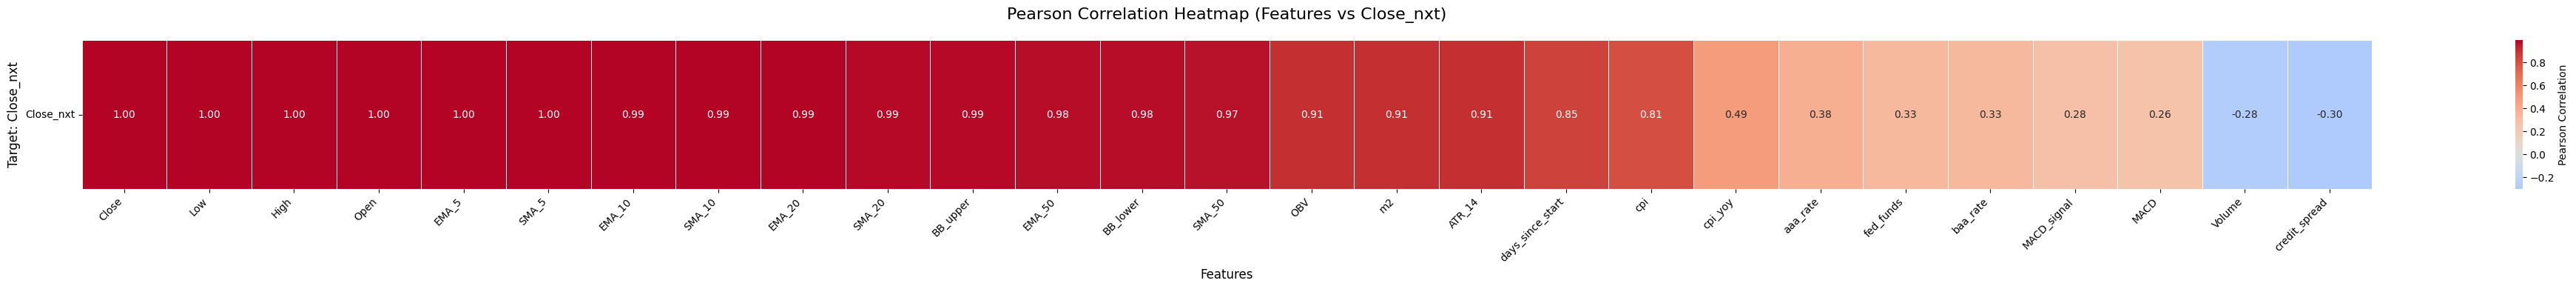


Top 20 Features Correlated with Close_nxt:
                  Close_nxt
Close              0.998114
Low                0.997680
High               0.997639
Open               0.996939
EMA_5              0.996690
SMA_5              0.996010
EMA_10             0.994313
SMA_10             0.992860
EMA_20             0.989372
SMA_20             0.986012
BB_upper           0.985029
EMA_50             0.976279
BB_lower           0.975081
SMA_50             0.965541
OBV                0.910627
m2                 0.908264
ATR_14             0.907820
days_since_start   0.850573
cpi                0.814302
cpi_yoy            0.486988


In [37]:
# -------- PEARSON CORRELATION VISUALIZATION -------
# Pearson pre-filter: keep only features with |corr| > 0.25 with target (like attempt3.5)
CORR_THRESHOLD = 0.25
corr_matrix = df[feature_cols + target_col].corr(method='pearson')
target_corr = corr_matrix[target_col].drop(target_col)
high_corr_mask = abs(target_corr[target_col[0]]) > CORR_THRESHOLD
feature_cols = [col for col in feature_cols if high_corr_mask[col]]
print(f"After Pearson pre-filter (|corr| > {CORR_THRESHOLD}): {len(feature_cols)} features")

# Compute correlations with the target
corr_matrix = df[feature_cols + target_col].corr(method='pearson')

# Extract correlations with target, sort descending
target_corr = corr_matrix[target_col].drop(target_col)
target_corr_sorted = target_corr.sort_values(by=target_col[0], ascending=False)

# Transpose for horizontal heatmap
target_corr_sorted = target_corr_sorted.transpose()

# Plot
plt.figure(figsize=(40, 4))
sns.heatmap(target_corr_sorted, 
            annot=True, 
            cmap='coolwarm', 
            center=0, 
            fmt='.2f',
            linewidths=0.5,
            cbar_kws={'label': 'Pearson Correlation'})
plt.title("Pearson Correlation Heatmap (Features vs Close_nxt)", fontsize=16, pad=20)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Target: Close_nxt", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

# Optional: Print top 20 most correlated features
print("\nTop 20 Features Correlated with Close_nxt:")
print(abs(target_corr[target_col]).sort_values(by=target_col[0], ascending=False).head(20))

In [38]:
# ============ LASSO VOTING Feature Selection (from attempt3.5) ======================
# Use TimeSeriesSplit to ensure no look-ahead bias in feature selection

# Prepare data (using only features, not target)
X = df[list(feature_cols)].values
y = df[target_col].values.ravel()

# Scale features
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# LASSO VOTING: Run LASSO across 5 time-series folds, count how often each feature is selected
tscv = TimeSeriesSplit(n_splits=5)
selection_counts = np.zeros(len(feature_cols), dtype=int)

print("Running LASSO voting across 5 time-series folds...")
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_scaled), 1):
    X_tr, y_tr = X_scaled[train_idx], y[train_idx]
    
    lasso = Lasso(alpha=0.01, max_iter=10000, random_state=42)
    lasso.fit(X_tr, y_tr)
    
    # Count which features were selected (non-zero coefficient)
    selected = (lasso.coef_ != 0).astype(int)
    selection_counts += selected
    
    selected_this_fold = np.sum(selected)
    print(f"  Fold {fold}: {selected_this_fold} features selected")

# Keep features selected in at least 4/5 folds (like attempt3.5)
MIN_VOTES = 4
keep_mask = selection_counts >= MIN_VOTES
selected_features = [feature_cols[i] for i, keep in enumerate(keep_mask) if keep]

print(f"\nLASSO Voting Results (selected in >= {MIN_VOTES}/5 folds):")
print(f"Selected {len(selected_features)} features: {selected_features}")
print(f"\nFeature selection counts:")
for i, (feat, count) in enumerate(zip(feature_cols, selection_counts)):
    if count > 0:
        print(f"  {feat}: {count}/5")

Running LASSO voting across 5 time-series folds...
  Fold 1: 6 features selected
  Fold 2: 7 features selected
  Fold 3: 11 features selected
  Fold 4: 15 features selected
  Fold 5: 14 features selected

LASSO Voting Results (selected in >= 4/5 folds):
Selected 5 features: ['Volume', 'MACD', 'MACD_signal', 'OBV', 'cpi_yoy']

Feature selection counts:
  Close: 3/5
  High: 3/5
  Low: 3/5
  Open: 2/5
  Volume: 5/5
  MACD: 5/5
  MACD_signal: 4/5
  BB_upper: 2/5
  ATR_14: 3/5
  OBV: 5/5
  days_since_start: 1/5
  fed_funds: 3/5
  baa_rate: 2/5
  aaa_rate: 2/5
  m2: 3/5
  credit_spread: 2/5
  cpi_yoy: 5/5


---
# 4. Data Preparation (using selected features)
Split **before** scaling to prevent data leakage. Use separate scalers for input features and the target column.

In [39]:

LOOKBACK    = 60
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15

TARGET_COL   = 'Close_nxt'
feature_cols = selected_features          # from lasso voting
if 'days_since_start' not in feature_cols:
    feature_cols.append('days_since_start')


n         = len(df)
train_end = int(n * TRAIN_RATIO)
val_end   = int(n * (TRAIN_RATIO + VAL_RATIO))

df_train = df.iloc[:train_end]
df_val   = df.iloc[train_end:val_end]
df_test  = df.iloc[val_end:]

# Fit scalers on train only to prevent leakage
feat_scaler   = RobustScaler()
target_scaler = RobustScaler()

train_X = feat_scaler.fit_transform(df_train[feature_cols])
val_X   = feat_scaler.transform(df_val[feature_cols])
test_X  = feat_scaler.transform(df_test[feature_cols])

train_y = target_scaler.fit_transform(df_train[[TARGET_COL]])
val_y   = target_scaler.transform(df_val[[TARGET_COL]])
test_y  = target_scaler.transform(df_test[[TARGET_COL]])

# Alias kept for compatibility with downstream cells
scaler = feat_scaler

print(f'Feature columns ({len(feature_cols)}): {feature_cols}')
print(f'Train: {len(df_train)}  Val: {len(df_val)}  Test: {len(df_test)} rows')


Feature columns (6): ['Volume', 'MACD', 'MACD_signal', 'OBV', 'cpi_yoy', 'days_since_start']
Train: 1574  Val: 337  Test: 338 rows


In [40]:
def create_sequences(features, target, lookback):
    """Slide a lookback window over (features, target) to build (X, y) arrays."""
    X, y = [], []
    for i in range(lookback, len(features)):
        X.append(features[i - lookback:i])
        y.append(target[i, 0])
    return np.array(X), np.array(y)


# Train
X_train, y_train = create_sequences(train_X, train_y, LOOKBACK)

# Validation: prepend the last LOOKBACK rows of train so the first
# val sequence has full context (no look-ahead into val)
val_X_ctx = np.vstack([train_X[-LOOKBACK:], val_X])
val_y_ctx = np.vstack([train_y[-LOOKBACK:], val_y])
X_val, y_val = create_sequences(val_X_ctx, val_y_ctx, LOOKBACK)

# Test: same idea — prepend the last LOOKBACK rows of val
test_X_ctx = np.vstack([val_X[-LOOKBACK:], test_X])
test_y_ctx = np.vstack([val_y[-LOOKBACK:], test_y])
X_test, y_test = create_sequences(test_X_ctx, test_y_ctx, LOOKBACK)

# Index into original df for aligning predictions to dates
test_start_idx = val_end

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_val  : {X_val.shape}    y_val  : {y_val.shape}')
print(f'X_test : {X_test.shape}   y_test : {y_test.shape}')


X_train: (1514, 60, 6)  y_train: (1514,)
X_val  : (337, 60, 6)    y_val  : (337,)
X_test : (338, 60, 6)   y_test : (338,)


---
# 5. Building and Training LSTM

In [41]:
# Force fresh hyperparameter tuning - delete cached tuner results
import shutil
import os
if os.path.exists('kt_results/lstm_tuning_v2'):
    shutil.rmtree('kt_results/lstm_tuning_v2')
    print("Deleted old kt_results - will run fresh hyperparameter tuning")
else:
    print("No existing kt_results found - starting fresh tuning")

# Hyperparameter tuning using KerasTuner (like attempt3.5)
%pip install keras-tuner tensorboard -q
import keras_tuner as kt
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
from keras.callbacks import EarlyStopping
import keras

# Define model builder for KerasTuner
def build_model(hp):
    model = Sequential([
        Input(shape=(LOOKBACK, X_train.shape[2])),
        LSTM(
            hp.Int('units1', min_value=32, max_value=128, step=32),
            return_sequences=True
        ),
        Dropout(hp.Float('dropout', min_value=0.1, max_value=0.3, step=0.1)),
        LSTM(
            hp.Int('units2', min_value=32, max_value=128, step=32),
            return_sequences=False
        ),
        Dropout(hp.Float('dropout', min_value=0.1, max_value=0.3, step=0.1)),
        Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice('learning_rate', values=[0.001, 0.0005])
        ),
        loss='mse',
        metrics=['mae']
    )
    return model

# Run Hyperband search
tuner = kt.Hyperband(
    build_model,
    objective='val_loss',
    max_epochs=50,
    factor=3,
    hyperband_iterations=2,
    directory='kt_results',
    project_name='lstm_tuning_v2'
)

tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1
)

# Get best hyperparameters
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best units1: {best_hp.get('units1')}")
print(f"Best units2: {best_hp.get('units2')}")
print(f"Best dropout: {best_hp.get('dropout')}")
print(f"Best learning_rate: {best_hp.get('learning_rate')}")

Trial 88 Complete [00h 02m 00s]
val_loss: 0.02181057259440422

Best val_loss So Far: 0.014042476192116737
Total elapsed time: 01h 13m 10s
Best units1: 96
Best units2: 128
Best dropout: 0.2
Best learning_rate: 0.001


In [42]:
# Build final model with best hyperparameters
model = Sequential([
    Input(shape=(LOOKBACK, X_train.shape[2])),
    LSTM(best_hp.get('units1'), return_sequences=True),
    Dropout(best_hp.get('dropout')),
    LSTM(best_hp.get('units2'), return_sequences=False),
    Dropout(best_hp.get('dropout')),
    Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_hp.get('learning_rate')),
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 96)         │        39,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       115,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 154,881 (605.00 KB)

 Trainable params: 154,881 (605.00 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 137ms/step - loss: 0.0669 - mae: 0.1656 - val_loss: 0.0853 - val_mae: 0.2438
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 147ms/step - loss: 0.0210 - mae: 0.0999 - val_loss: 0.0287 - val_mae: 0.1494
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 146ms/step - loss: 0.0161 - mae: 0.0874 - val_loss: 0.0453 - val_mae: 0.1687
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - loss: 0.0135 - mae: 0.0778 - val_loss: 0.0432 - val_mae: 0.1697
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 132ms/step - loss: 0.0130 - mae: 0.0758 - val_loss: 0.0260 - val_mae: 0.1335
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/step - loss: 0.0112 - mae: 0.0708 - val_loss: 0.0293 - val_mae: 0.1308
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 135ms/step - loss: 0.0106 - mae: 0.0721 - val_loss: 0.0388 - val_mae: 0.1527
Epoch 8/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 156ms/step - loss: 0.0093 - mae: 0.0651 - val_loss: 0.0457 - val_mae: 0.1734
Epoch 9/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 12

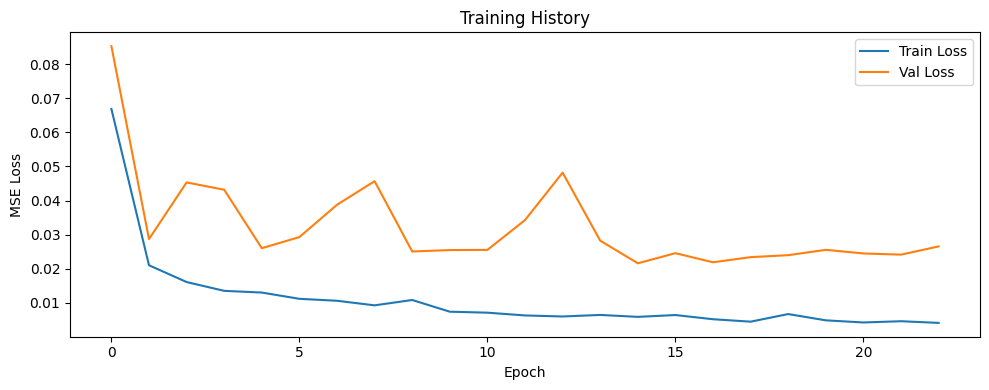

In [44]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

---
# 6. Making Predictions

In [45]:
pred_scaled = model.predict(X_test)

prediction = target_scaler.inverse_transform(pred_scaled)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))

print(f'Predictions shape: {prediction.shape}')
print(f'Actuals shape     : {y_test_actual.shape}')

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step
Predictions shape: (338, 1)
Actuals shape     : (338, 1)


---
# 7. Visualisation

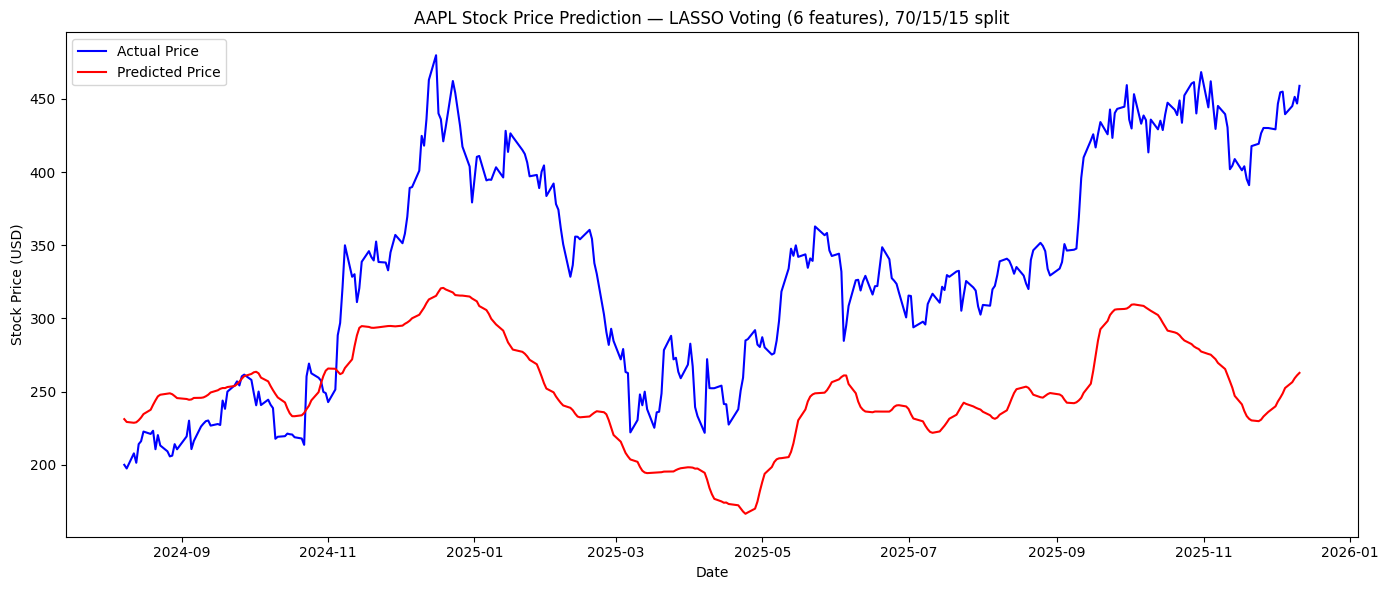

In [46]:
test_dates = df.index[test_start_idx:test_start_idx + len(X_test)]

plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test_actual.flatten(), label='Actual Price',    color='blue')
plt.plot(test_dates, prediction.flatten(),    label='Predicted Price', color='red')
plt.title(f'AAPL Stock Price Prediction \u2014 LASSO Voting '
          f'({len(feature_cols)} features), 70/15/15 split')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()


---
# 8. Model Evaluation

In [47]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse  = mean_squared_error(y_test_actual, prediction)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_actual, prediction)
mape = np.mean(np.abs((y_test_actual - prediction) / y_test_actual)) * 100

print('=' * 55)
print(f'LSTM with LASSO Voting Features ({len(feature_cols)}) - 70/15/15 split')
print(f'Features: {feature_cols}')
print('=' * 55)
print(f'  MSE  : {mse:.4f}')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAE  : {mae:.4f}')
print(f'  MAPE : {mape:.2f}%')
print('=' * 55)

LSTM with LASSO Voting Features (6) - 70/15/15 split
Features: ['Volume', 'MACD', 'MACD_signal', 'OBV', 'cpi_yoy', 'days_since_start']
  MSE  : 10428.2986
  RMSE : 102.1190
  MAE  : 88.7327
  MAPE : 24.94%


 1/11 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


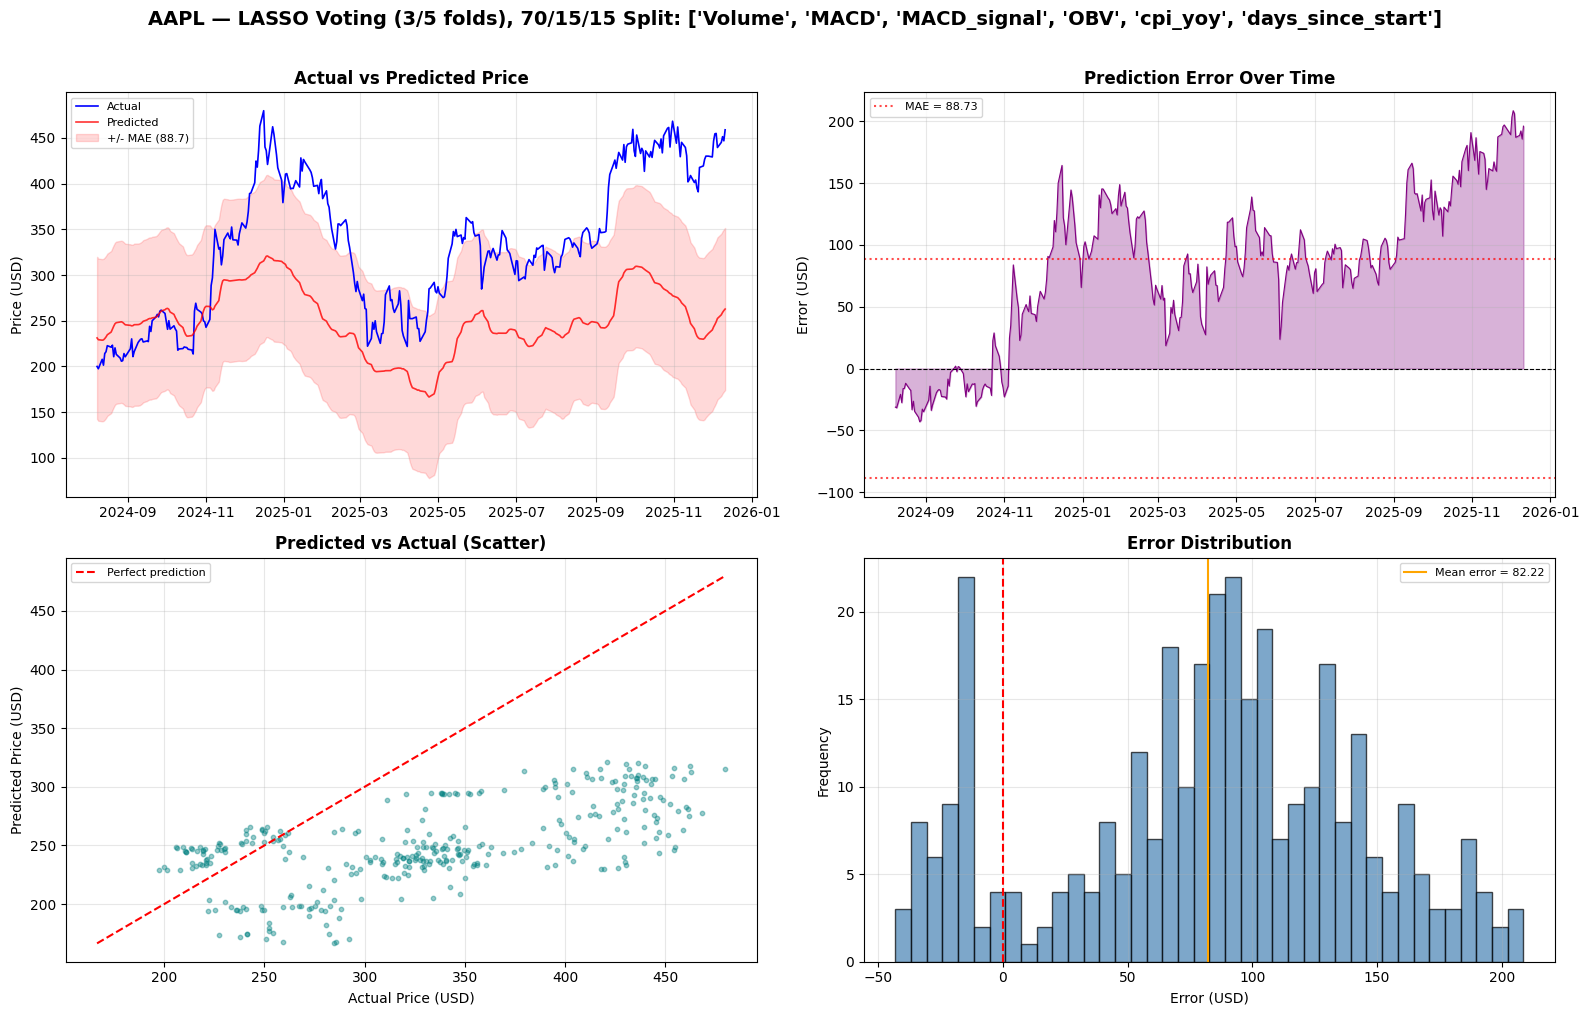

Mean Error: 82.2173  |  Std Error: 60.5691
Max Over-prediction: 208.6614  |  Max Under-prediction: -43.1172
Mean Abs % Error: 24.94%


In [48]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

pred_scaled = model.predict(X_test)
prediction = target_scaler.inverse_transform(pred_scaled)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))
test_dates = df.index[test_start_idx:test_start_idx + len(X_test)]

mse  = mean_squared_error(y_test_actual, prediction)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_actual, prediction)
mape = np.mean(np.abs((y_test_actual - prediction) / y_test_actual)) * 100

errors = y_test_actual.flatten() - prediction.flatten()
pct_errors = (errors / y_test_actual.flatten()) * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.plot(test_dates, y_test_actual.flatten(), label='Actual', color='blue', linewidth=1.2)
ax.plot(test_dates, prediction.flatten(), label='Predicted', color='red', linewidth=1.2, alpha=0.8)
ax.fill_between(test_dates, prediction.flatten() - mae, prediction.flatten() + mae,
                alpha=0.15, color='red', label=f'+/- MAE ({mae:.1f})')
ax.set_title('Actual vs Predicted Price', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(test_dates, errors, color='purple', linewidth=0.8)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.axhline(y=mae, color='red', linestyle=':', alpha=0.7, label=f'MAE = {mae:.2f}')
ax.axhline(y=-mae, color='red', linestyle=':', alpha=0.7)
ax.fill_between(test_dates, errors, 0, alpha=0.3, color='purple')
ax.set_title('Prediction Error Over Time', fontweight='bold')
ax.set_ylabel('Error (USD)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.scatter(y_test_actual.flatten(), prediction.flatten(), alpha=0.4, s=10, color='teal')
min_val = min(y_test_actual.min(), prediction.min())
max_val = max(y_test_actual.max(), prediction.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Price (USD)')
ax.set_ylabel('Predicted Price (USD)')
ax.set_title('Predicted vs Actual (Scatter)', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.hist(errors, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
ax.axvline(x=errors.mean(), color='orange', linestyle='-', linewidth=1.5,
           label=f'Mean error = {errors.mean():.2f}')
ax.set_xlabel('Error (USD)')
ax.set_ylabel('Frequency')
ax.set_title('Error Distribution', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle(f'AAPL — LASSO Voting (3/5 folds), 70/15/15 Split: {feature_cols}', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Mean Error: {errors.mean():.4f}  |  Std Error: {errors.std():.4f}')
print(f'Max Over-prediction: {errors.max():.4f}  |  Max Under-prediction: {errors.min():.4f}')
print(f'Mean Abs % Error: {np.abs(pct_errors).mean():.2f}%')